# Explore here

In [ ]:
# Your code here
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import chi2, SelectKBest
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.feature_selection import SelectKBest, f_regression
import numpy as np


In [117]:
df = pd.read_csv('https://breathecode.herokuapp.com/asset/internal-link?id=929&path=medical_insurance_cost.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [118]:
df.to_csv('../data/raw/total_data.csv')

In [119]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


/tmp/ipykernel_969/1232415225.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(ax=axis[1, 0], data=df, x="region", palette="magma")


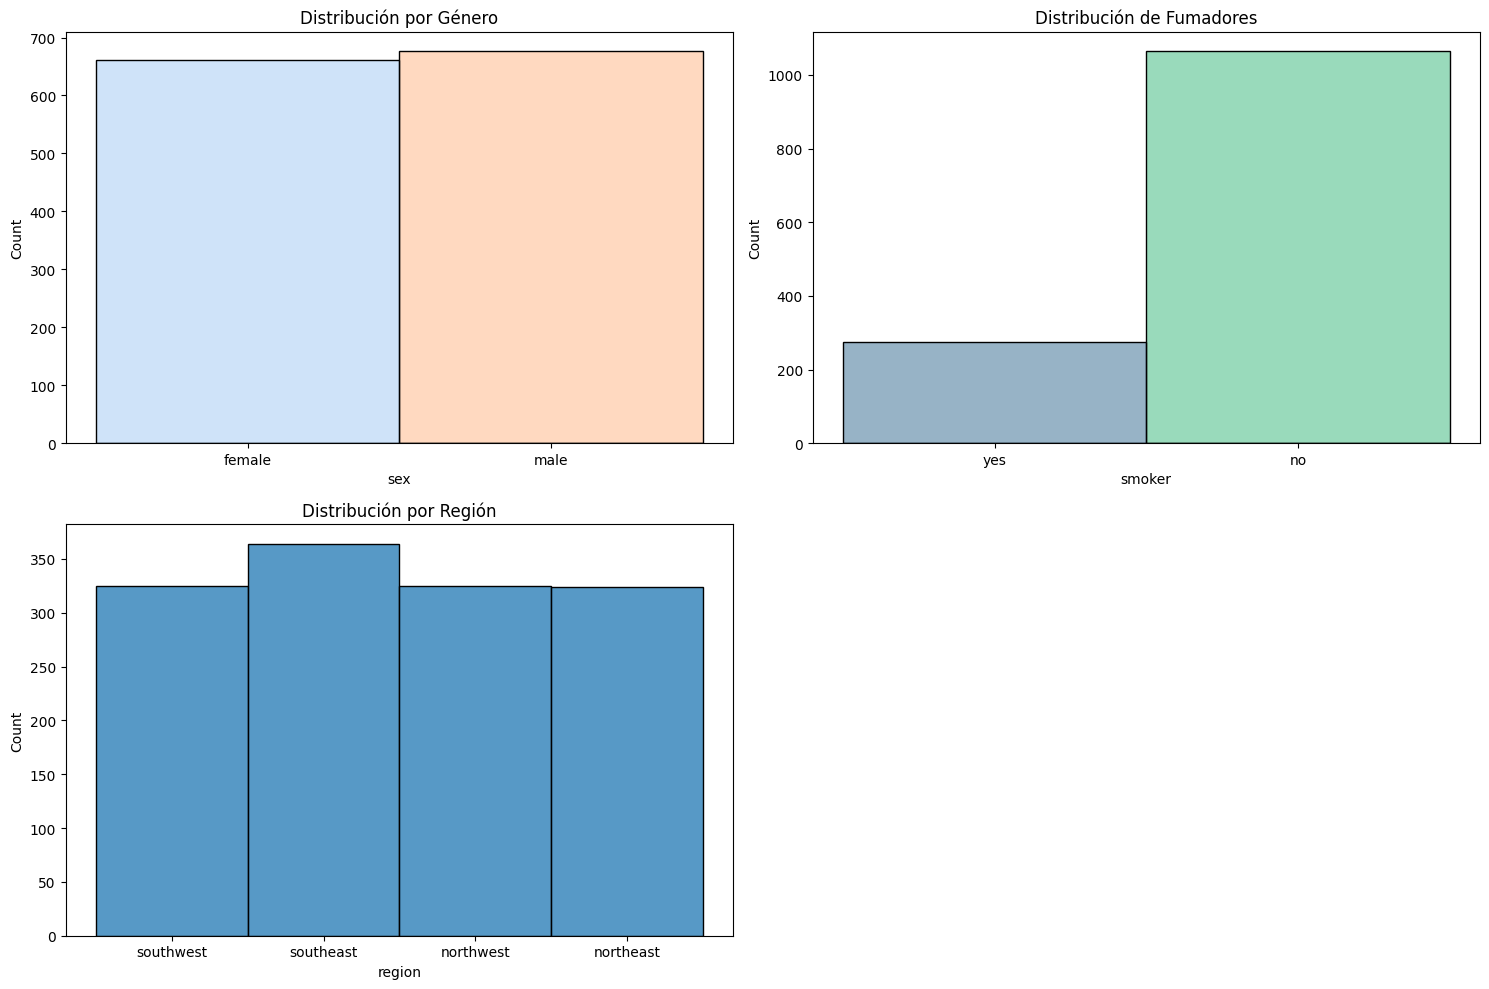

In [120]:
fig, axis = plt.subplots(2, 2, figsize=(15, 10))

sns.histplot(ax=axis[0, 0], data=df, x="sex", hue="sex", legend=False, palette="pastel")
axis[0, 0].set_title("Distribución por Género")
sns.histplot(ax=axis[0, 1], data=df, x="smoker", hue="smoker", legend=False, palette="viridis")
axis[0, 1].set_title("Distribución de Fumadores")
sns.histplot(ax=axis[1, 0], data=df, x="region", palette="magma")
axis[1, 0].set_title("Distribución por Región")
axis[1, 1].axis('off')

plt.tight_layout()
plt.show()

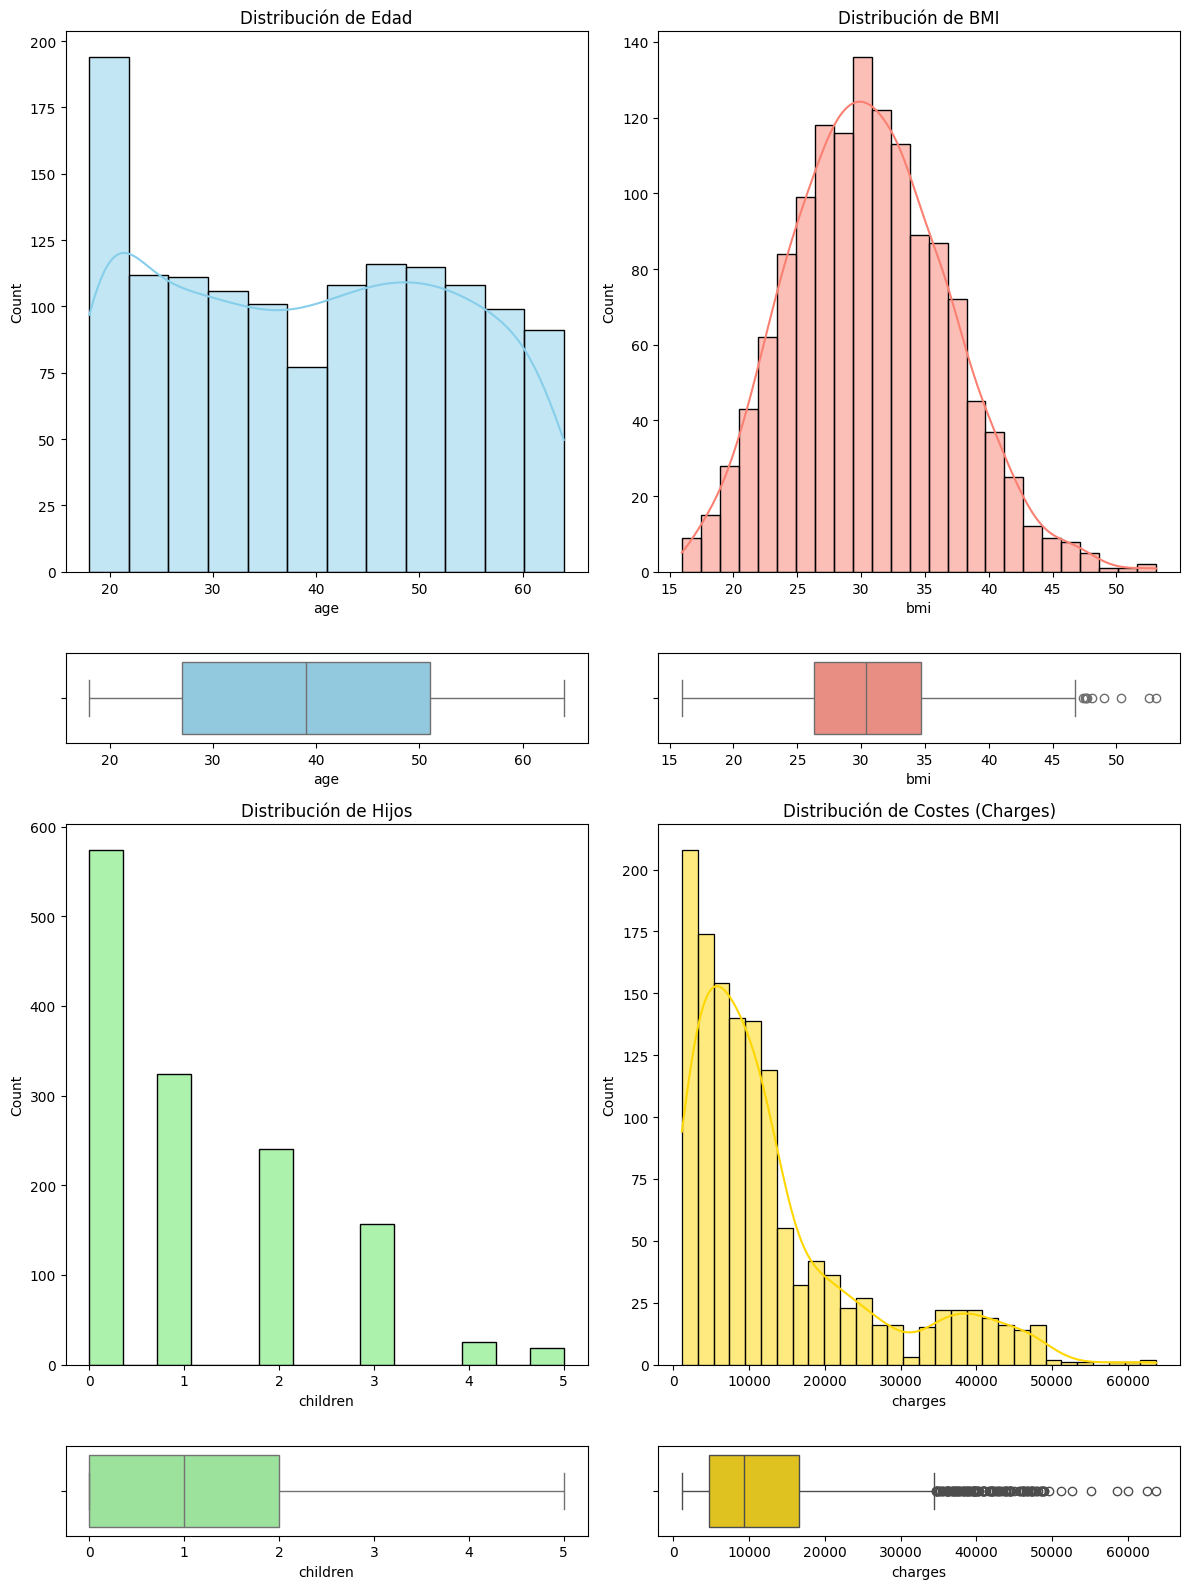

In [121]:
fig, axis = plt.subplots(4, 2, figsize=(12, 16), gridspec_kw={'height_ratios': [6, 1, 6, 1]})


sns.histplot(ax=axis[0, 0], data=df, x="age", kde=True, color="skyblue")
axis[0, 0].set_title("Distribución de Edad")
sns.boxplot(ax=axis[1, 0], data=df, x="age", color="skyblue")


sns.histplot(ax=axis[0, 1], data=df, x="bmi", kde=True, color="salmon")
axis[0, 1].set_title("Distribución de BMI")
sns.boxplot(ax=axis[1, 1], data=df, x="bmi", color="salmon")


sns.histplot(ax=axis[2, 0], data=df, x="children", color="lightgreen")
axis[2, 0].set_title("Distribución de Hijos")
sns.boxplot(ax=axis[3, 0], data=df, x="children", color="lightgreen")


sns.histplot(ax=axis[2, 1], data=df, x="charges", kde=True, color="gold")
axis[2, 1].set_title("Distribución de Costes (Charges)")
sns.boxplot(ax=axis[3, 1], data=df, x="charges", color="gold")

plt.tight_layout()
plt.show()

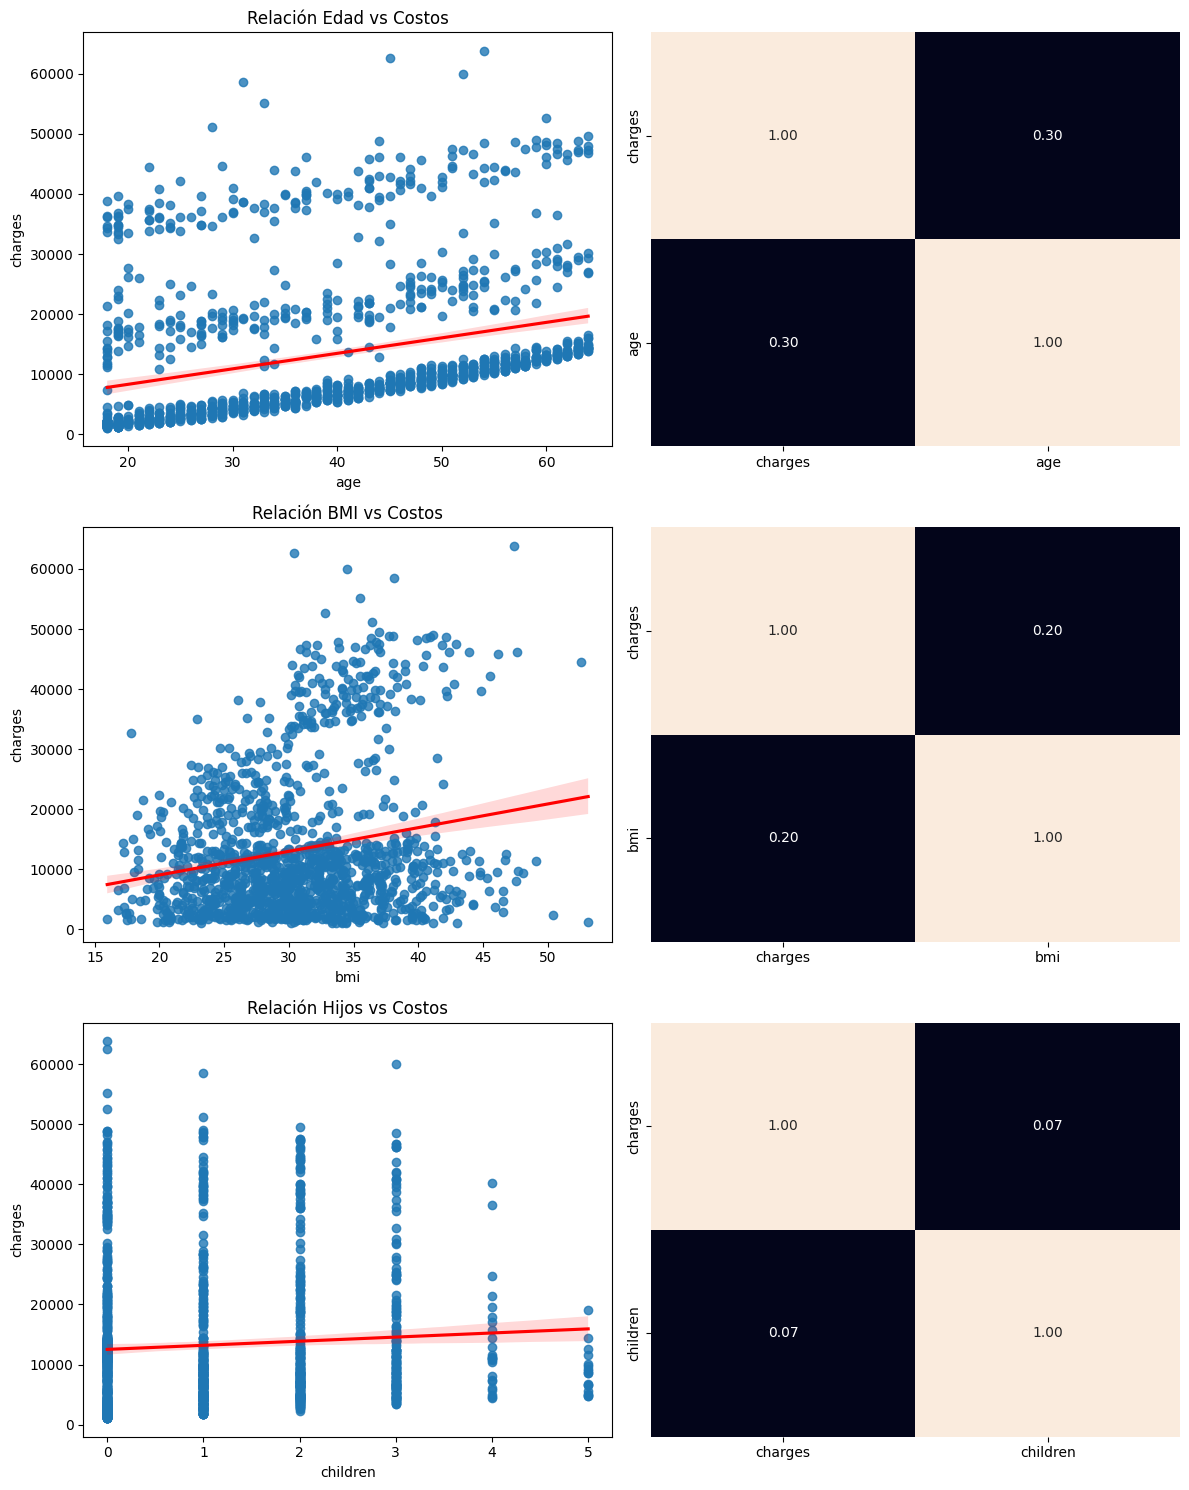

In [122]:
fig, axis = plt.subplots(3, 2, figsize=(12, 15))

sns.regplot(ax=axis[0, 0], data=df, x="age", y="charges", line_kws={"color": "red"})
axis[0, 0].set_title("Relación Edad vs Costos")
sns.heatmap(df[["charges", "age"]].corr(), annot=True, fmt=".2f", ax=axis[0, 1], cbar=False)


sns.regplot(ax=axis[1, 0], data=df, x="bmi", y="charges", line_kws={"color": "red"})
axis[1, 0].set_title("Relación BMI vs Costos")
sns.heatmap(df[["charges", "bmi"]].corr(), annot=True, fmt=".2f", ax=axis[1, 1], cbar=False)


sns.regplot(ax=axis[2, 0], data=df, x="children", y="charges", line_kws={"color": "red"})
axis[2, 0].set_title("Relación Hijos vs Costos")
sns.heatmap(df[["charges", "children"]].corr(), annot=True, fmt=".2f", ax=axis[2, 1], cbar=False)

plt.tight_layout()
plt.show()

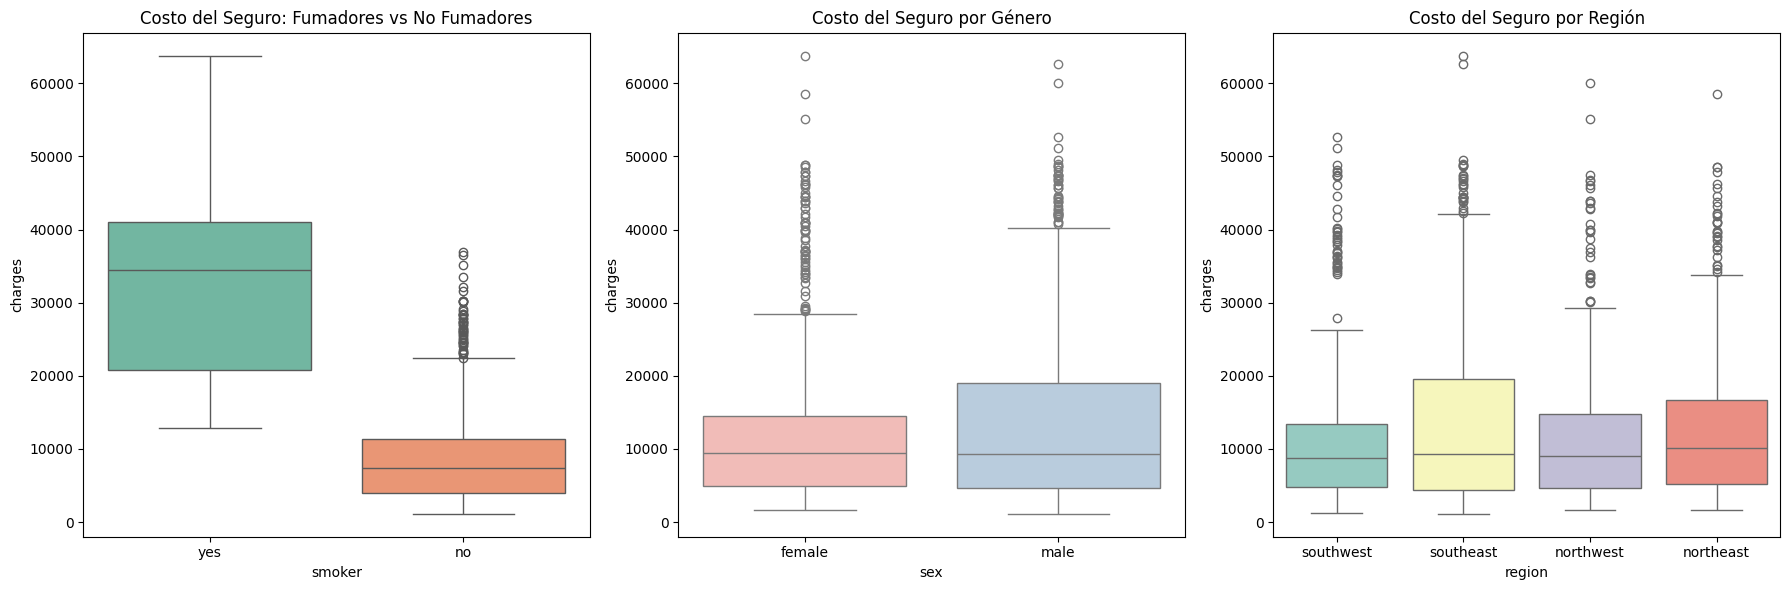

In [123]:
fig, axis = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(ax=axis[0], data=df, x="smoker", y="charges", hue="smoker", palette="Set2", legend=False)
axis[0].set_title("Costo del Seguro: Fumadores vs No Fumadores")

sns.boxplot(ax=axis[1], data=df, x="sex", y="charges", hue="sex", palette="Pastel1", legend=False)
axis[1].set_title("Costo del Seguro por Género")

sns.boxplot(ax=axis[2], data=df, x="region", y="charges", hue="region", palette="Set3", legend=False)
axis[2].set_title("Costo del Seguro por Región")

plt.tight_layout()
plt.show()

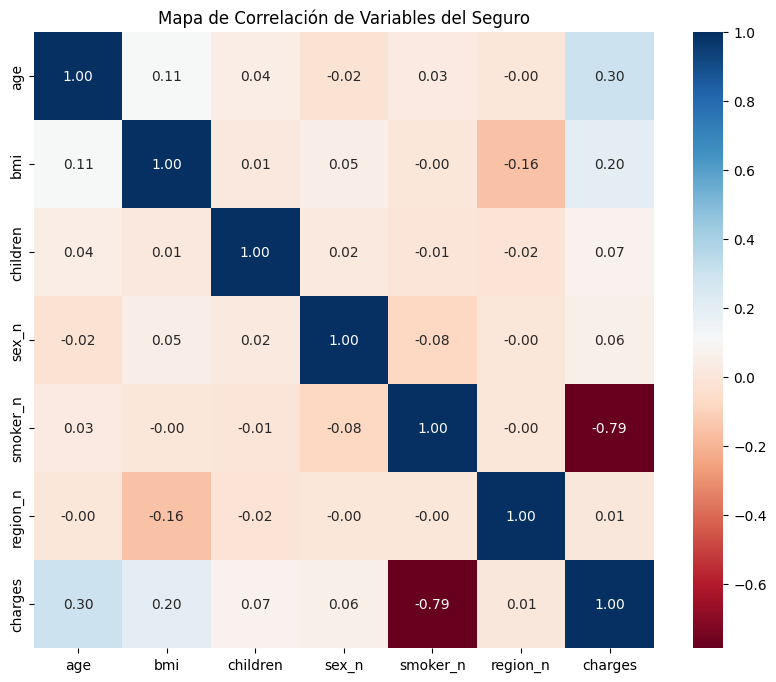

In [124]:
df['sex_n'] = pd.factorize(df['sex'])[0]
df['smoker_n'] = pd.factorize(df['smoker'])[0]
df['region_n'] = pd.factorize(df['region'])[0]

# 2. Creamos el mapa de calor con TODAS las variables (numéricas originales + factorizadas)
plt.figure(figsize=(10, 8))
sns.heatmap(df[["age", "bmi", "children", "sex_n", "smoker_n", "region_n", "charges"]].corr(), 
            annot=True, 
            fmt='.2f', 
            cmap="RdBu")

plt.title("Mapa de Correlación de Variables del Seguro")
plt.show()



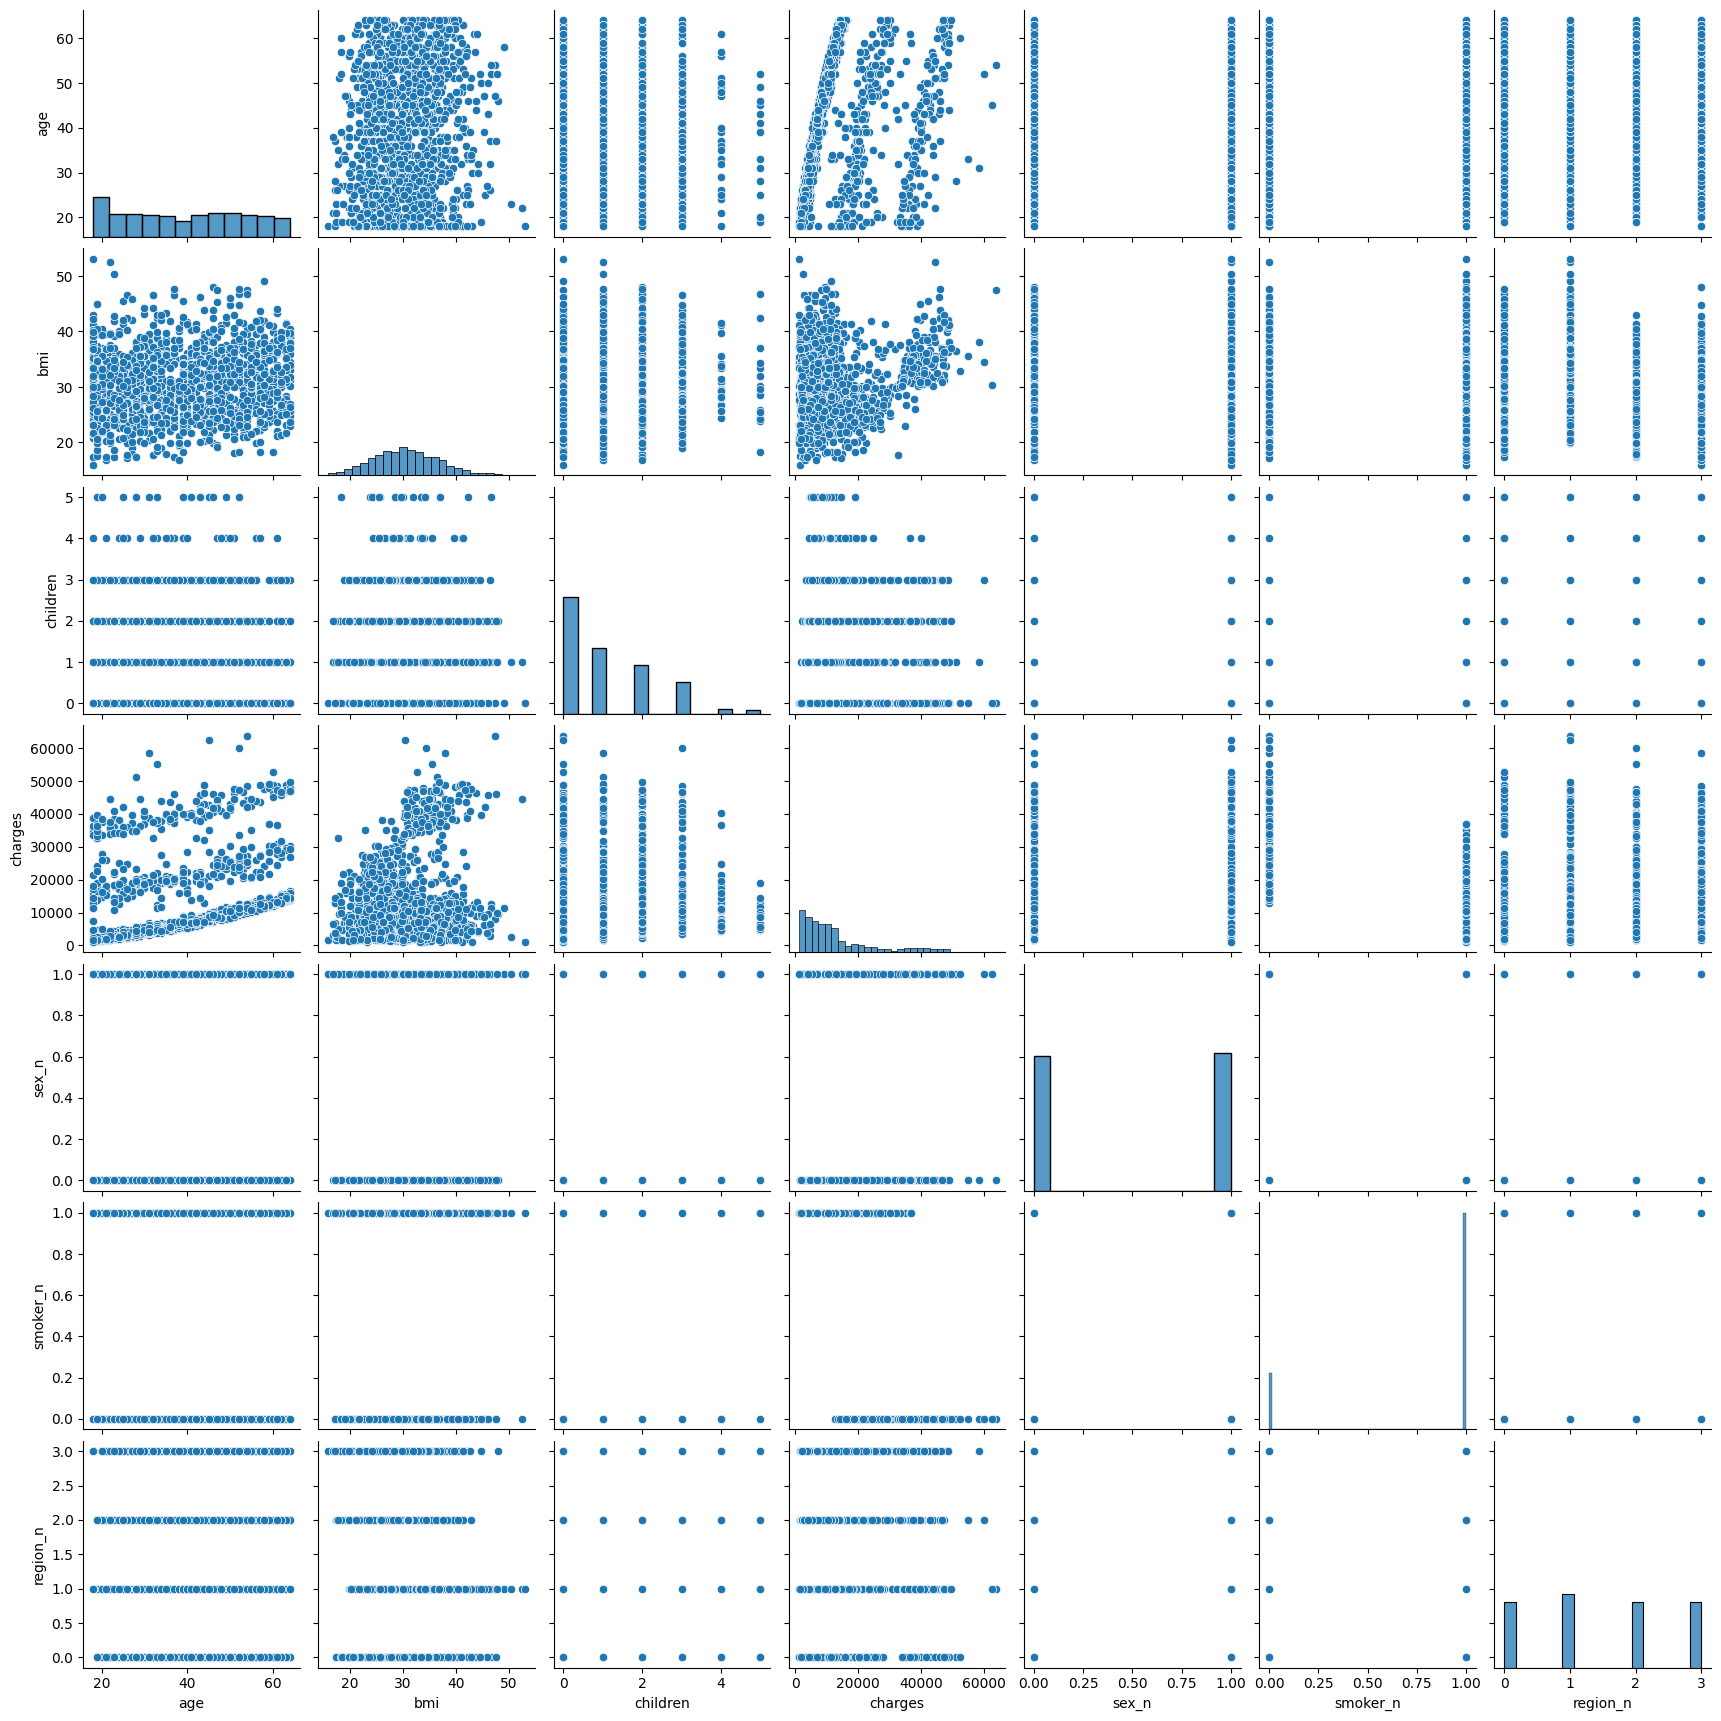

In [125]:
sns.pairplot(data=df)

In [156]:
df.describe()

,age,bmi,charges,smoker_n
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,13270.422265,0.795217
std,14.049960,6.098187,12110.011237,0.403694
min,18.000000,15.960000,1121.873900,0.000000
25%,27.000000,26.296250,4740.287150,1.000000
50%,39.000000,30.400000,9382.033000,1.000000
75%,51.000000,34.693750,16639.912515,1.000000
max,64.000000,53.130000,63770.428010,1.000000


In [139]:
estadisticas_charges = df['charges'].describe() 
estadisticas_charges

count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64

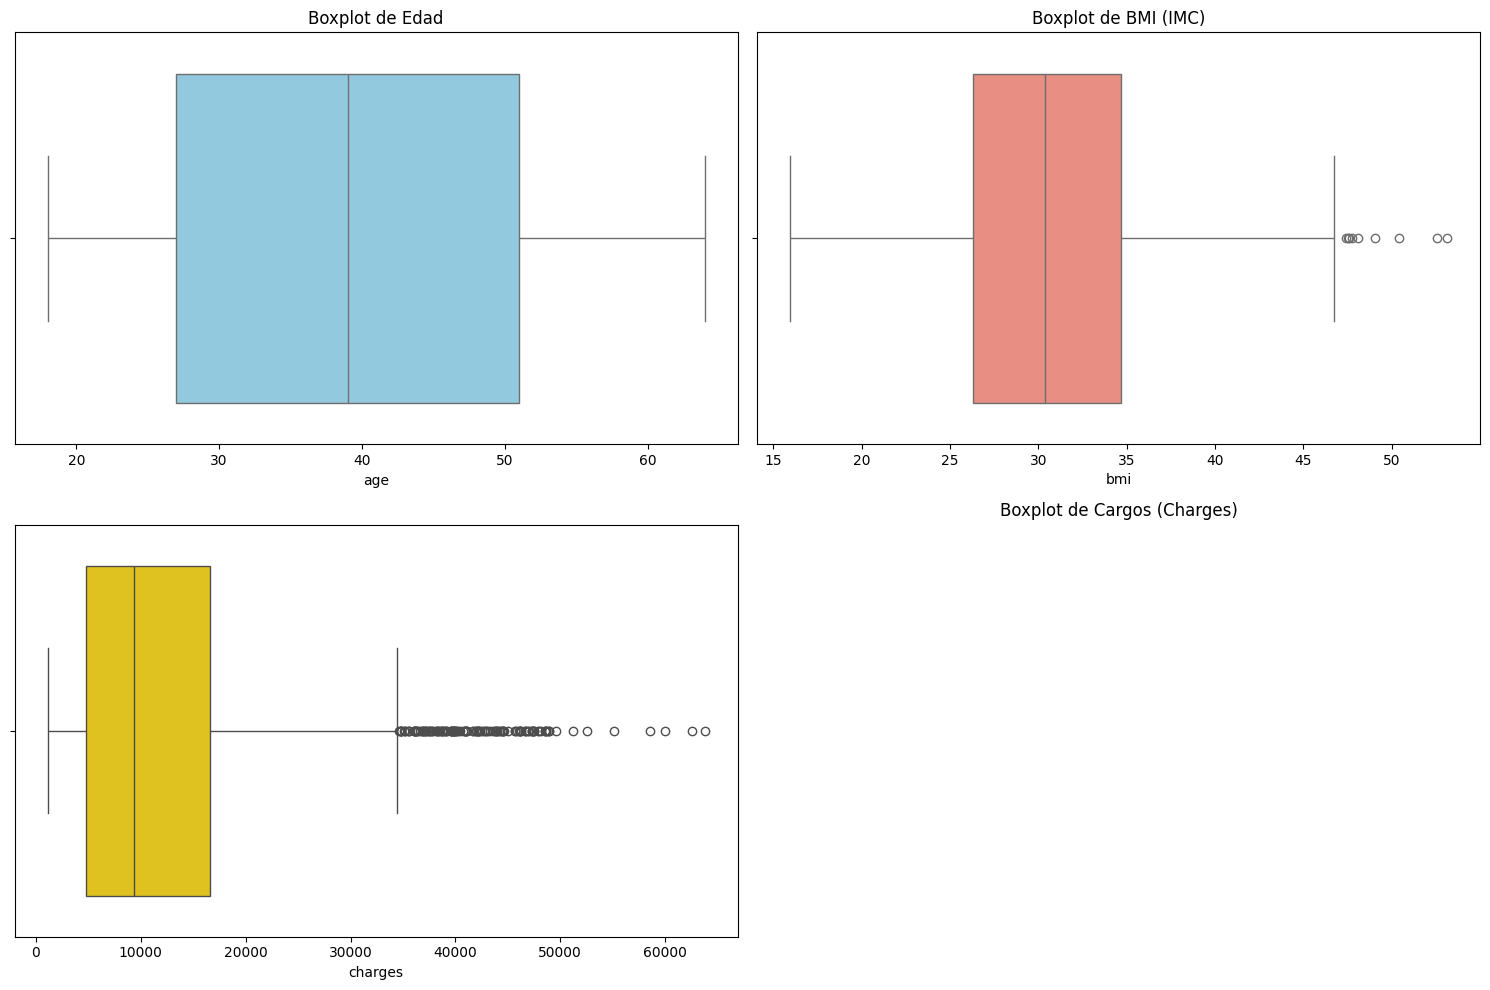

In [136]:
fig, axis = plt.subplots(2, 2, figsize=(15, 10))

sns.boxplot(ax=axis[0, 0], data=df, x="age", color="skyblue")
axis[0, 0].set_title("Boxplot de Edad")

sns.boxplot(ax=axis[0, 1], data=df, x="bmi", color="salmon")
axis[0, 1].set_title("Boxplot de BMI (IMC)")

sns.boxplot(ax=axis[1, 0], data=df, x="charges", color="gold")
axis[1, 1].set_title("Boxplot de Cargos (Charges)")

axis[1, 1].axis('off')



plt.tight_layout()
plt.show()

In [131]:
estadisticas_charges = df['charges'].describe()

riq_charges = estadisticas_charges['75%'] - estadisticas_charges['25%']

limite_superior_charges = estadisticas_charges['75%'] + 1.5 * riq_charges
limite_inferior_charges = estadisticas_charges['25%'] - 1.5 * riq_charges

print(f"El RIQ de cargos es: {riq_charges:.2f}")
print(f"El límite superior es: {limite_superior_charges:.2f}")
print(f"El límite inferior es: {limite_inferior_charges:.2f}")

El RIQ de cargos es: 11899.63
El límite superior es: 34489.35
El límite inferior es: -13109.15


In [137]:
df[df['charges']>34489.35]

,age,sex,bmi,smoker,region,charges,smoker_n
14,27,male,42.130,yes,southeast,39611.75770,0
19,30,male,35.300,yes,southwest,36837.46700,0
23,34,female,31.920,yes,northeast,37701.87680,0
29,31,male,36.300,yes,southwest,38711.00000,0
30,22,male,35.600,yes,southwest,35585.57600,0
...,...,...,...,...,...,...,...
1300,45,male,30.360,yes,southeast,62592.87309,0
1301,62,male,30.875,yes,northwest,46718.16325,0
1303,43,male,27.800,yes,southwest,37829.72420,0
1313,19,female,34.700,yes,southwest,36397.57600,0


In [140]:
df['age'].describe()

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

In [141]:
estadisticas_age = df['age'].describe()

riq_age = estadisticas_age['75%'] - estadisticas_age['25%']

limite_superior_age = estadisticas_age['75%'] + 1.5 * riq_age
limite_inferior_age = estadisticas_age['25%'] - 1.5 * riq_age

print(f"El RIQ de edad es: {riq_age:.2f}")
print(f"El límite superior para edad es: {limite_superior_age:.2f}")
print(f"El límite inferior para edad es: {limite_inferior_age:.2f}")

El RIQ de edad es: 24.00
El límite superior para edad es: 87.00
El límite inferior para edad es: -9.00


In [142]:
df ['bmi'].describe()

count    1338.000000
mean       30.663397
std         6.098187
min        15.960000
25%        26.296250
50%        30.400000
75%        34.693750
max        53.130000
Name: bmi, dtype: float64

In [143]:
estadisticas_bmi = df['bmi'].describe()

riq_bmi = estadisticas_bmi['75%'] - estadisticas_bmi['25%']

limite_superior_bmi = estadisticas_bmi['75%'] + 1.5 * riq_bmi
limite_inferior_bmi = estadisticas_bmi['25%'] - 1.5 * riq_bmi

print(f"El RIQ de bmi es: {riq_bmi:.2f}")
print(f"El límite superior para bmi es: {limite_superior_bmi:.2f}")
print(f"El límite inferior para bmi es: {limite_inferior_bmi:.2f}")

El RIQ de bmi es: 8.40
El límite superior para bmi es: 47.29
El límite inferior para bmi es: 13.70


In [144]:
df[(df['bmi'] <= 47.29)]
df

,age,sex,bmi,smoker,region,charges,smoker_n
0,19,female,27.900,yes,southwest,16884.92400,0
1,18,male,33.770,no,southeast,1725.55230,1
2,28,male,33.000,no,southeast,4449.46200,1
3,33,male,22.705,no,northwest,21984.47061,1
4,32,male,28.880,no,northwest,3866.85520,1
...,...,...,...,...,...,...,...
1333,50,male,30.970,no,northwest,10600.54830,1
1334,18,female,31.920,no,northeast,2205.98080,1
1335,18,female,36.850,no,southeast,1629.83350,1
1336,21,female,25.800,no,southwest,2007.94500,1


In [154]:
df.isnull().sum()

age         0
sex         0
bmi         0
smoker      0
region      0
charges     0
smoker_n    0
dtype: int64

In [158]:
num_variables = ['age' , 'bmi' , 'charges' , 'smoker_n']

scaler = MinMaxScaler()
columnas_escaladas = scaler.fit_transform(df[num_variables])
df_escalado = pd.DataFrame(columnas_escaladas, index=df.index, columns=num_variables)

df_escalado['charges'] = df['charges']

df_escalado.head()

,age,bmi,charges,smoker_n
0,0.021739,0.321227,16884.92400,0.0
1,0.000000,0.479150,1725.55230,1.0
2,0.217391,0.458434,4449.46200,1.0
3,0.326087,0.181464,21984.47061,1.0
4,0.304348,0.347592,3866.85520,1.0


In [162]:
X = df_escalado.drop('charges', axis=1)
y = df_escalado['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo_seleccion = SelectKBest(score_func=f_regression, k='all')
modelo_seleccion.fit(X_train, y_train)

ix = modelo_seleccion.get_support()
X_train_sel = pd.DataFrame(modelo_seleccion.transform(X_train), columns=X_train.columns.values[ix])
X_test_sel = pd.DataFrame(modelo_seleccion.transform(X_test), columns=X_test.columns.values[ix])

X_train_sel['charges'] = y_train.values
X_test_sel['charges'] = y_test.values

X_train_sel.head()

,age,bmi,smoker_n,charges
0,0.608696,0.107345,1.0,9193.83850
1,0.630435,0.224913,1.0,8534.67180
2,0.739130,0.239440,1.0,27117.99378
3,0.456522,0.493947,1.0,8596.82780
4,0.782609,0.148238,1.0,12475.35130


In [163]:
train_para_csv = X_train_sel.copy()
test_para_csv = X_test_sel.copy()

train_para_csv['charges'] = y_train.values
test_para_csv['charges'] = y_test.values


train_para_csv.to_csv('../data/processed/entrenamiento_seguros_limpio.csv', index=False)
test_para_csv.to_csv('../data/processed/test_seguros_limpio.csv', index=False)



In [165]:
X_entrenamiento = X_train_sel.drop(columns=['charges'])


y_entrenamiento = y_train

modelo_final = LinearRegression()
modelo_final.fit(X_entrenamiento, y_entrenamiento)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [166]:
print(f"Intercepto (Punto de partida): {modelo_final.intercept_}")
print(f"Coeficientes (Peso de cada variable): {modelo_final.coef_}")

Intercepto (Punto de partida): 21847.09890044787
Coeficientes (Peso de cada variable): [ 11932.86941266  12134.15512912 -23675.37184666]


In [174]:
y_pred = modelo_final.predict(X_entrenamiento)

y_pred

array([ 6737.74920953,  8423.74692866,  9897.08107714, ...,
       11556.374128  , 37104.7781336 , 12320.62086106], shape=(1070,))

In [176]:
from sklearn.metrics import root_mean_squared_error, r2_score



X_test_final = X_test_sel.drop(columns=['charges'])
y_pred_test = modelo_final.predict(X_test_final)


rmse = root_mean_squared_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)


print(f'El RMSE es de: {rmse}')
print(f'R2 es de: {r2}')

El RMSE es de: 5874.763304187488
R2 es de: 0.7776932310583375
